#Modelo Predictivo de Visibilidad y Seguridad Vial en la RN3


##Introducción
La Ruta Nacional N.º 3 es la principal conexión terrestre dentro de la Isla Grande de Tierra del Fuego y resulta fundamental para unir ciudades, transportar mercadería y permitir el traslado diario de muchas personas. Sin embargo, quienes transitamos habitualmente esta ruta sabemos que las condiciones climáticas representan un problema constante, especialmente en sectores como el Paso Garibaldi, donde el relieve montañoso y el clima fueguino generan situaciones muy peligrosas para conducir.
En muchas ocasiones, al trasladarme dentro de la isla, pude observar cómo la niebla densa, la niebla de hielo y el viento blanco reducen la visibilidad de forma repentina, convirtiendo la conducción en una situación de alto riesgo. En cuestión de minutos, la ruta puede quedar cubierta por una especie de “pared” de niebla o nieve en suspensión que dificulta la orientación de los conductores y aumenta considerablemente las probabilidades de accidentes. Esta problemática se vio reflejada en los últimos años con numerosos despistes y situaciones de emergencia en distintos sectores de la Ruta Nacional N.º 3, involucrando vehículos particulares, camiones y transportes de pasajeros afectados por las condiciones climáticas adversas.
A partir de esta problemática surge la importancia de este proyecto, que busca utilizar datos meteorológicos históricos para desarrollar una herramienta predictiva capaz de anticipar escenarios de baja visibilidad. Contar con un modelo de este tipo permitiría mejorar la toma de decisiones sobre la transitabilidad de la ruta, emitir alertas tempranas y contribuir a una mayor seguridad para todas las personas que circulan por este corredor tan importante de la provincia.


##Objetivo General
Desarrollar un modelo de Aprendizaje Automático supervisado, utilizando la librería scikit-learn, que permita clasificar de manera temprana condiciones de riesgo vial por pérdida crítica de visibilidad en la Ruta Nacional N.º 3 a partir de variables meteorológicas locales, con el objetivo de emitir alertas tempranas sobre posibles escenarios de baja visibilidad y peligro para la circulación.


#Origen del dataset
Los datos meteorológicos utilizados en este proyecto fueron obtenidos de
Meteostat, una plataforma de acceso abierto que brinda información climática
histórica de distintas partes del mundo. Para el análisis se seleccionaron las
estaciones meteorológicas oficiales de las dos principales ciudades de la
provincia de Tierra del Fuego: Ushuaia (representativa de la zona sur y
cordillerana) y Río Grande (representativa de la zona norte y esteparia).
Durante la recopilación de los datos surgió una dificultad importante. Al
descargar grandes períodos de tiempo de manera automática, algunas variables
relevantes no se incluían correctamente, especialmente la columna coco (Código
de Condición Climática), que resulta fundamental para el entrenamiento
supervisado de los modelos utilizados en este trabajo.
Para solucionar este problema, se optó por realizar las descargas en períodos
más pequeños, organizados de forma semanal para cada ciudad. De esta
manera se logró obtener la información completa y garantizar la presencia de
todas las variables necesarias. El período analizado abarca desde enero de 2023
hasta abril de 2026.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

## Carga de data set

In [ ]:
dataset = pd.read_excel('dataset Rio Grande- Ushuaia.xlsx')

In [ ]:
dataset.head()

,ciudad,time,temp,dwpt,rhum,prcp,snow,wdir,wspd,wpgt,pres,tsun,coco
0,Ushuaia,2023-01-01 00:00:00,11.5,3.5,58.0,0.0,NaN,320.0,14.8,NaN,977.3,NaN,4.0
1,Rio Grande,2023-01-01 00:00:00,9.0,4.0,71.0,0.0,NaN,290.0,38.9,NaN,982.0,NaN,3.0
2,Ushuaia,2023-01-01 01:00:00,8.2,5.7,84.0,0.0,NaN,230.0,57.6,NaN,978.2,NaN,7.0
3,Rio Grande,2023-01-01 01:00:00,7.6,4.9,83.0,0.0,NaN,290.0,55.4,NaN,982.6,NaN,3.0
4,Ushuaia,2023-01-01 02:00:00,7.9,3.9,76.0,0.0,NaN,230.0,46.4,NaN,979.3,NaN,7.0


### Buscar registros duplicados según fecha y ciudad

In [ ]:
duplicados = dataset[dataset.duplicated(
    subset=['time', 'ciudad'],
    keep=False
)]

print(duplicados.sort_values(['time', 'ciudad']))

        ciudad time  temp  dwpt  rhum  prcp  snow   wdir  wspd  wpgt    pres  \
58200  Ushuaia  NaT   7.0   1.1  66.0   0.0   NaN  110.0   4.0   NaN  1002.0   
58201  Ushuaia  NaT   6.0   2.1  76.0   0.0   NaN  360.0   4.0   NaN  1001.0   
58202  Ushuaia  NaT   6.0   2.1  76.0   0.0   NaN  360.0  11.0   NaN  1001.0   
58203  Ushuaia  NaT   7.0   2.1  71.0   0.0   NaN   50.0   9.0   NaN  1001.0   
58204  Ushuaia  NaT   7.0   3.1  76.0   0.0   NaN   50.0   9.0   NaN   999.0   
...        ...  ...   ...   ...   ...   ...   ...    ...   ...   ...     ...   
58363  Ushuaia  NaT  13.0   4.9  58.0   0.0   NaN  240.0  24.0   NaN  1003.0   
58364  Ushuaia  NaT  12.0   4.9  62.0   0.0   NaN  230.0  26.0  24.0  1003.0   
58365  Ushuaia  NaT  12.0   4.9  62.0   0.0   NaN  230.0  26.0   NaN  1002.0   
58366  Ushuaia  NaT  11.0   5.1  67.0   0.0   NaN  230.0  17.0   NaN  1002.0   
58367  Ushuaia  NaT  11.0   5.1  67.0   0.0   NaN  228.0   1.0   NaN  1002.0   

       tsun  coco  
58200   NaN   3.0  

### Variables meteorológicas a utilizar

In [ ]:
variables = [
    'temp', 'dwpt', 'rhum', 'prcp', 'snow',
    'wdir', 'wspd', 'wpgt', 'pres', 'tsun', 'coco'
]

### Reestructurar el dataset para tener una fila por fecha y columnas separadas para cada ciudad

In [ ]:
df_modelo = pd.pivot_table(
    dataset,
    index='time',
    columns='ciudad',
    values=variables,
    aggfunc='mean'
)



### Unificar nombres de columnas

In [ ]:
df_modelo.columns = [
    f'{var}_{ciudad}'
    for var, ciudad in df_modelo.columns
]

### Convertir el índice temporal nuevamente en columna

In [ ]:
df_modelo = df_modelo.reset_index()

### Contar duplicados restantes

In [ ]:
print(
    dataset.duplicated(
        subset=['time', 'ciudad']
    ).sum()
)

167


### Obtener nuevamente los registros duplicados.

In [ ]:
duplicados = dataset[dataset.duplicated(
    subset=['time','ciudad'],
    keep=False
)]

print(duplicados[['time','ciudad']].sort_values(['time','ciudad']))

      time   ciudad
58200  NaT  Ushuaia
58201  NaT  Ushuaia
58202  NaT  Ushuaia
58203  NaT  Ushuaia
58204  NaT  Ushuaia
...    ...      ...
58363  NaT  Ushuaia
58364  NaT  Ushuaia
58365  NaT  Ushuaia
58366  NaT  Ushuaia
58367  NaT  Ushuaia

[168 rows x 2 columns]


### Mostrar cantidad de filas y columnas del conjunto de duplicados.

In [ ]:
print(duplicados.shape)

(168, 13)


### Contar registros con fecha faltante

In [ ]:
print(dataset['time'].isna().sum())

168


### Verificar nuevamente la cantidad de duplicados.

In [ ]:
print(
    dataset.duplicated(
        subset=['time','ciudad']
    ).sum()
)

167


### Extraer las filas que tienen fecha faltante.

In [ ]:
filas_sin_fecha = dataset[dataset['time'].isna()]
print(filas_sin_fecha.head())

        ciudad time  temp  dwpt  rhum  prcp  snow   wdir  wspd  wpgt    pres  \
58200  Ushuaia  NaT   7.0   1.1  66.0   0.0   NaN  110.0   4.0   NaN  1002.0   
58201  Ushuaia  NaT   6.0   2.1  76.0   0.0   NaN  360.0   4.0   NaN  1001.0   
58202  Ushuaia  NaT   6.0   2.1  76.0   0.0   NaN  360.0  11.0   NaN  1001.0   
58203  Ushuaia  NaT   7.0   2.1  71.0   0.0   NaN   50.0   9.0   NaN  1001.0   
58204  Ushuaia  NaT   7.0   3.1  76.0   0.0   NaN   50.0   9.0   NaN   999.0   

       tsun  coco  
58200   NaN   3.0  
58201   NaN   2.0  
58202   NaN   2.0  
58203   NaN   3.0  
58204   NaN   3.0  


#### Analizar a qué ciudad pertenecen los registros sin información temporal.

In [ ]:
print(dataset[dataset['time'].isna()]['ciudad'].value_counts())

ciudad
Ushuaia    168
Name: count, dtype: int64


### Mostrar las primeras 20 filas con fecha faltante.

In [ ]:
dataset[dataset['time'].isna()].head(20)

,ciudad,time,temp,dwpt,rhum,prcp,snow,wdir,wspd,wpgt,pres,tsun,coco
58200,Ushuaia,NaT,7.0,1.1,66.0,0.0,NaN,110.0,4.0,NaN,1002.0,NaN,3.0
58201,Ushuaia,NaT,6.0,2.1,76.0,0.0,NaN,360.0,4.0,NaN,1001.0,NaN,2.0
58202,Ushuaia,NaT,6.0,2.1,76.0,0.0,NaN,360.0,11.0,NaN,1001.0,NaN,2.0
58203,Ushuaia,NaT,7.0,2.1,71.0,0.0,NaN,50.0,9.0,NaN,1001.0,NaN,3.0
58204,Ushuaia,NaT,7.0,3.1,76.0,0.0,NaN,50.0,9.0,NaN,999.0,NaN,3.0
58205,Ushuaia,NaT,5.0,2.0,81.0,0.0,NaN,21.0,2.0,NaN,999.0,NaN,3.0
58206,Ushuaia,NaT,6.0,3.0,81.0,0.0,NaN,240.0,11.0,NaN,998.0,NaN,3.0
58207,Ushuaia,NaT,8.0,2.0,66.0,0.0,NaN,310.0,9.0,NaN,998.0,NaN,3.0
58208,Ushuaia,NaT,9.0,2.1,62.0,0.0,NaN,20.0,17.0,NaN,998.0,NaN,3.0
58209,Ushuaia,NaT,11.0,3.1,58.0,0.0,NaN,184.0,9.0,NaN,997.0,NaN,3.0


# Limpieza del dataset


### Eliminar registros que no poseen fecha

In [ ]:
dataset = dataset.dropna(subset=['time'])

### Confirmar que no quedan valores faltantes

In [ ]:
print(dataset['time'].isna().sum())

0


# Generacion del dataset final


In [ ]:
variables = [
    'temp','dwpt','rhum','prcp','snow',
    'wdir','wspd','wpgt','pres','tsun','coco'
]

df_modelo = pd.pivot_table(
    dataset,
    index='time',
    columns='ciudad',
    values=variables
)

df_modelo.columns = [
    f'{var}_{ciudad}'
    for var, ciudad in df_modelo.columns
]

df_modelo = df_modelo.reset_index()

print(df_modelo.shape)
df_modelo.head()

(29184, 27)


,time,coco_Rio Grande,coco_Ushuaia,coco_ciudad,dwpt_Rio Grande,dwpt_Ushuaia,dwpt_ciudad,prcp_Rio Grande,prcp_Ushuaia,prcp_ciudad,...,temp_Ushuaia,temp_ciudad,wdir_Rio Grande,wdir_Ushuaia,wdir_ciudad,wpgt_Rio Grande,wpgt_Ushuaia,wspd_Rio Grande,wspd_Ushuaia,wspd_ciudad
0,2023-01-01 00:00:00,3.0,4.0,NaN,4.0,3.5,NaN,0.0,0.0,NaN,...,11.5,NaN,290.0,320.0,NaN,NaN,NaN,38.9,14.8,NaN
1,2023-01-01 01:00:00,3.0,7.0,NaN,4.9,5.7,NaN,0.0,0.0,NaN,...,8.2,NaN,290.0,230.0,NaN,NaN,NaN,55.4,57.6,NaN
2,2023-01-01 02:00:00,3.0,7.0,NaN,4.2,3.9,NaN,0.0,0.0,NaN,...,7.9,NaN,290.0,230.0,NaN,NaN,NaN,57.6,46.4,NaN
3,2023-01-01 03:00:00,3.0,7.0,NaN,2.4,2.9,NaN,0.0,0.0,NaN,...,8.0,NaN,270.0,230.0,NaN,NaN,NaN,44.6,55.4,NaN
4,2023-01-01 04:00:00,3.0,7.0,NaN,1.9,2.8,NaN,0.0,0.1,NaN,...,7.5,NaN,270.0,230.0,NaN,NaN,NaN,50.0,53.6,NaN


### Eliminar todas las columnas que terminen en '_ciudad'

In [ ]:
columnas_a_borrar = [col for col in df_modelo.columns if col.endswith('_ciudad')]
df_modelo = df_modelo.drop(columns=columnas_a_borrar)
df_modelo.head()

,time,coco_Rio Grande,coco_Ushuaia,dwpt_Rio Grande,dwpt_Ushuaia,prcp_Rio Grande,prcp_Ushuaia,pres_Rio Grande,pres_Ushuaia,rhum_Rio Grande,rhum_Ushuaia,temp_Rio Grande,temp_Ushuaia,wdir_Rio Grande,wdir_Ushuaia,wpgt_Rio Grande,wpgt_Ushuaia,wspd_Rio Grande,wspd_Ushuaia
0,2023-01-01 00:00:00,3.0,4.0,4.0,3.5,0.0,0.0,982.0,977.3,71.0,58.0,9.0,11.5,290.0,320.0,NaN,NaN,38.9,14.8
1,2023-01-01 01:00:00,3.0,7.0,4.9,5.7,0.0,0.0,982.6,978.2,83.0,84.0,7.6,8.2,290.0,230.0,NaN,NaN,55.4,57.6
2,2023-01-01 02:00:00,3.0,7.0,4.2,3.9,0.0,0.0,983.5,979.3,81.0,76.0,7.2,7.9,290.0,230.0,NaN,NaN,57.6,46.4
3,2023-01-01 03:00:00,3.0,7.0,2.4,2.9,0.0,0.0,984.6,979.7,74.0,70.0,6.7,8.0,270.0,230.0,NaN,NaN,44.6,55.4
4,2023-01-01 04:00:00,3.0,7.0,1.9,2.8,0.0,0.1,985.2,980.4,70.0,72.0,7.0,7.5,270.0,230.0,NaN,NaN,50.0,53.6



### Estructura general del dataset pivoteado

In [ ]:
df_modelo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29184 entries, 0 to 29183
Data columns (total 19 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   time             29184 non-null  datetime64[ns]
 1   coco_Rio Grande  28708 non-null  float64       
 2   coco_Ushuaia     29013 non-null  float64       
 3   dwpt_Rio Grande  29151 non-null  float64       
 4   dwpt_Ushuaia     29012 non-null  float64       
 5   prcp_Rio Grande  28708 non-null  float64       
 6   prcp_Ushuaia     28537 non-null  float64       
 7   pres_Rio Grande  29142 non-null  float64       
 8   pres_Ushuaia     29013 non-null  float64       
 9   rhum_Rio Grande  29151 non-null  float64       
 10  rhum_Ushuaia     29012 non-null  float64       
 11  temp_Rio Grande  29156 non-null  float64       
 12  temp_Ushuaia     29013 non-null  float64       
 13  wdir_Rio Grande  29154 non-null  float64       
 14  wdir_Ushuaia     29013 non-null  float


### Resumen estadístico de las variables principales de ambas ciudades

In [ ]:
print(df_modelo[['temp_Rio Grande', 'temp_Ushuaia', 'rhum_Rio Grande', 'rhum_Ushuaia', 'prcp_Rio Grande', 'prcp_Ushuaia']].describe())

       temp_Rio Grande  temp_Ushuaia  rhum_Rio Grande  rhum_Ushuaia  \
count     29156.000000  29013.000000     29151.000000  29012.000000   
mean          6.198518      6.400510        74.310007     73.239005   
std           5.393077      4.221587        17.644447     13.597683   
min         -12.600000     -6.000000        20.000000     19.000000   
25%           2.200000      3.400000        62.000000     64.000000   
50%           6.000000      6.000000        78.000000     75.000000   
75%          10.000000      9.000000        88.000000     84.000000   
max          25.000000     25.000000       100.000000    100.000000   

       prcp_Rio Grande  prcp_Ushuaia  
count     28708.000000  28537.000000  
mean          0.054783      0.119179  
std           0.235702      0.320964  
min           0.000000      0.000000  
25%           0.000000      0.000000  
50%           0.000000      0.000000  
75%           0.000000      0.100000  
max           8.200000      7.500000  


## Matriz de correlacion de las variables meteorologicas de ambas ciudades


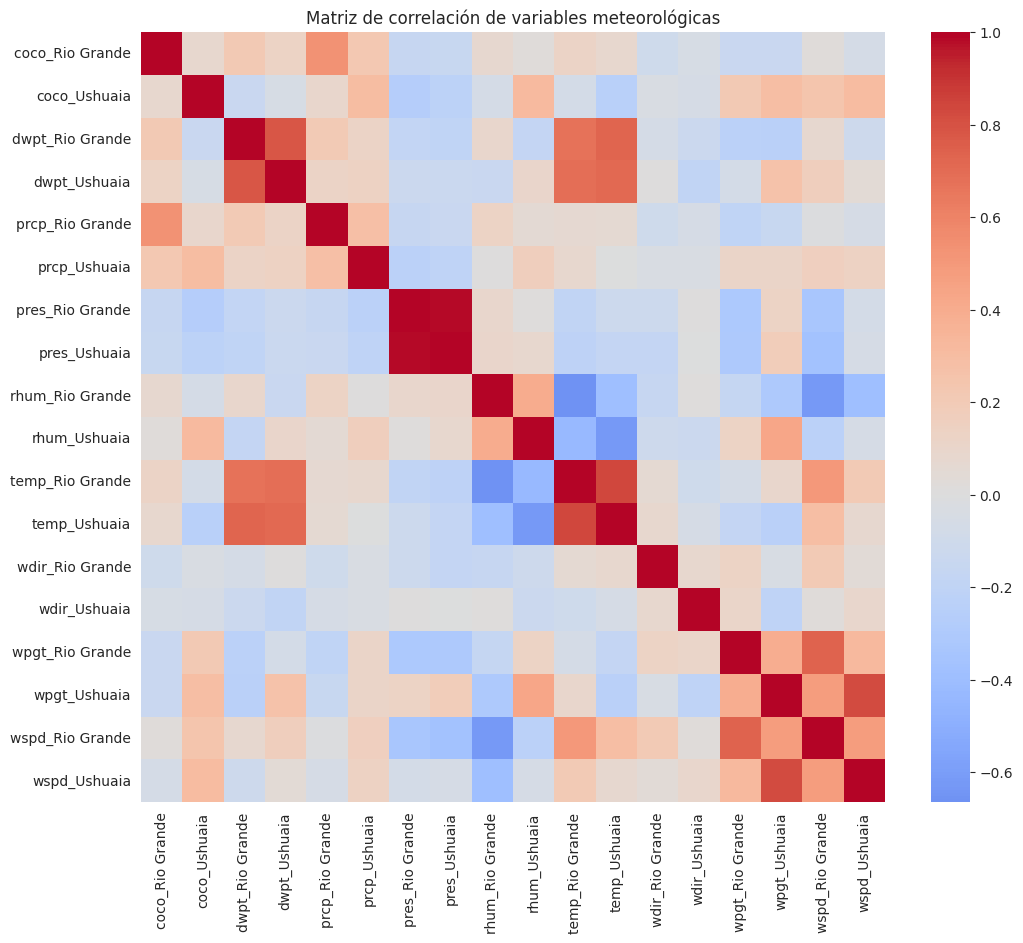

In [ ]:
plt.figure(figsize=(12,10))

corr = df_modelo.corr(numeric_only=True)

sns.heatmap(
    corr,
    cmap='coolwarm',
    center=0
)

plt.title('Matriz de correlación de variables meteorológicas')

plt.show()

La matriz de correlación general permite visualizar simultáneamente las relaciones existentes entre todas las variables meteorológicas registradas en las ciudades de Río Grande y Ushuaia. Los colores rojizos representan correlaciones positivas, mientras que los tonos azulados indican correlaciones negativas. Cuanto más intenso es el color, mayor es la fuerza de la relación.

Se observa una fuerte correlación positiva entre las temperaturas de ambas ciudades, lo que indica que los cambios térmicos suelen producirse de manera similar en toda la provincia. Del mismo modo, las variables relacionadas con el punto de rocío (dwpt) presentan correlaciones elevadas entre ambas localidades, reflejando patrones atmosféricos compartidos.
Las variables de velocidad y ráfaga de viento también muestran asociaciones positivas importantes tanto dentro de cada ciudad como entre ciudades, evidenciando que los eventos de viento intenso suelen afectar a la región de manera conjunta. En contraste, la humedad relativa presenta correlaciones negativas moderadas con la temperatura, indicando que los períodos más cálidos suelen estar asociados a una menor humedad relativa del aire.

Ademas que nos muestra que  la presión atmosférica mantiene correlaciones negativas débiles a moderadas con la temperatura y la velocidad del viento, sugiriendo que las condiciones de baja presión suelen estar asociadas con situaciones meteorológicas más dinámicas y ventosas.


## Matriz de correlaciones de la ciudad de rio grande

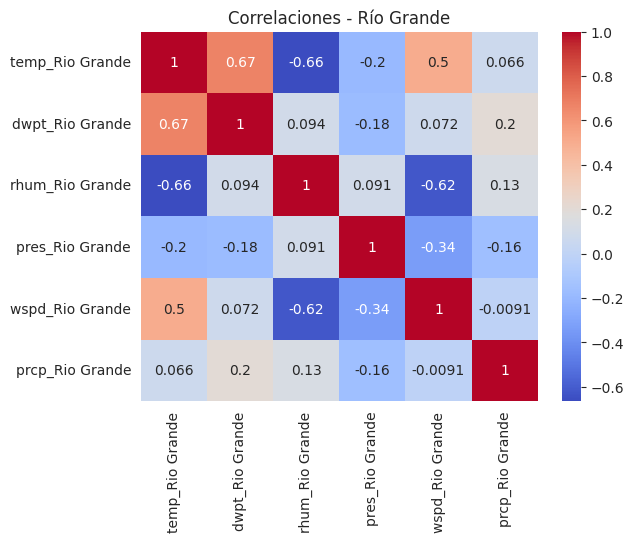

In [ ]:
corr_RG = df_modelo[[
    "temp_Rio Grande",
    "dwpt_Rio Grande",
    "rhum_Rio Grande",
    "pres_Rio Grande",
    "wspd_Rio Grande",
    "prcp_Rio Grande"
]].corr()

sns.heatmap(
    corr_RG,
    cmap='coolwarm',
    annot=True
)

plt.title("Correlaciones - Río Grande")

plt.show()

El análisis específico para Río Grande muestra que la temperatura presenta una correlación positiva con el punto de rocío (0,67), lo que indica que cuando aumenta la temperatura también tiende a incrementarse la cantidad de vapor de agua presente en la atmósfera.
Tambien se observa una correlación negativa considerable entre temperatura y humedad relativa (-0,66). Este comportamiento es esperable, ya que al aumentar la temperatura la capacidad del aire para contener vapor de agua se incrementa, reduciendo la humedad relativa si la cantidad de humedad disponible permanece constante.
La velocidad del viento presenta una correlación positiva moderada con la temperatura ( 0,50), sugiriendo que las jornadas más cálidas suelen estar acompañadas por vientos de mayor intensidad. Por otro lado, la humedad relativa y la velocidad del viento exhiben una correlación negativa relativamente fuerte (-0,62), indicando que las condiciones más secas suelen coincidir con velocidades de viento más elevadas.
La presión atmosférica muestra correlaciones negativas débiles con la temperatura (-0,20) y con la velocidad del viento (-0,34), mientras que la precipitación presenta relaciones muy bajas con el resto de las variables analizadas. Esto sugiere que las precipitaciones en Río Grande dependen de una combinación más compleja de factores meteorológicos y no de una única variable dominante.


## Matriz de correlaciones de la ciudad de Ushuaia

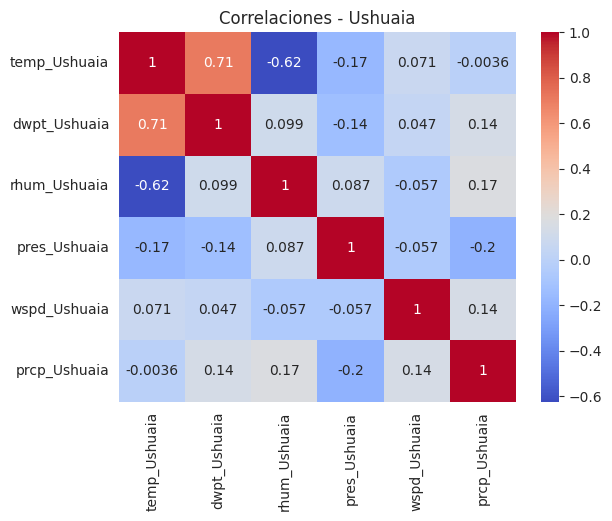

In [ ]:
corr_USH = df_modelo[[
    "temp_Ushuaia",
    "dwpt_Ushuaia",
    "rhum_Ushuaia",
    "pres_Ushuaia",
    "wspd_Ushuaia",
    "prcp_Ushuaia"
]].corr()

sns.heatmap(
    corr_USH,
    cmap='coolwarm',
    annot=True
)

plt.title("Correlaciones - Ushuaia")

plt.show()

En el analisis puntualizado de  Ushuaia se observan patrones similares a los registrados en Río Grande. La relación más destacada corresponde a la temperatura y el punto de rocío, con una correlación positiva de 0,71, ligeramente superior a la observada en Río Grande. Esto indica una fuerte asociación entre el calentamiento del aire y el incremento del contenido de humedad atmosférica.
La temperatura también presenta una correlación negativa importante con la humedad relativa (-0,62), confirmando que las condiciones más cálidas suelen asociarse con menores niveles de humedad relativa. Sin embargo, a diferencia de Río Grande, la velocidad del viento muestra una relación prácticamente nula con la temperatura (0,07), lo que indica que ambas variables evolucionan de forma relativamente independiente en Ushuaia.
La presión atmosférica mantiene correlaciones negativas débiles tanto con la temperatura (-0,17) como con la precipitación (-0,20), mientras que las precipitaciones presentan relaciones muy bajas con la mayoría de las variables meteorológicas analizadas. Esto sugiere que los eventos de lluvia o nieve en Ushuaia están influenciados por múltiples factores atmosféricos y no pueden explicarse únicamente mediante las variables consideradas en este análisis.


## Distribución de coco por ciudad

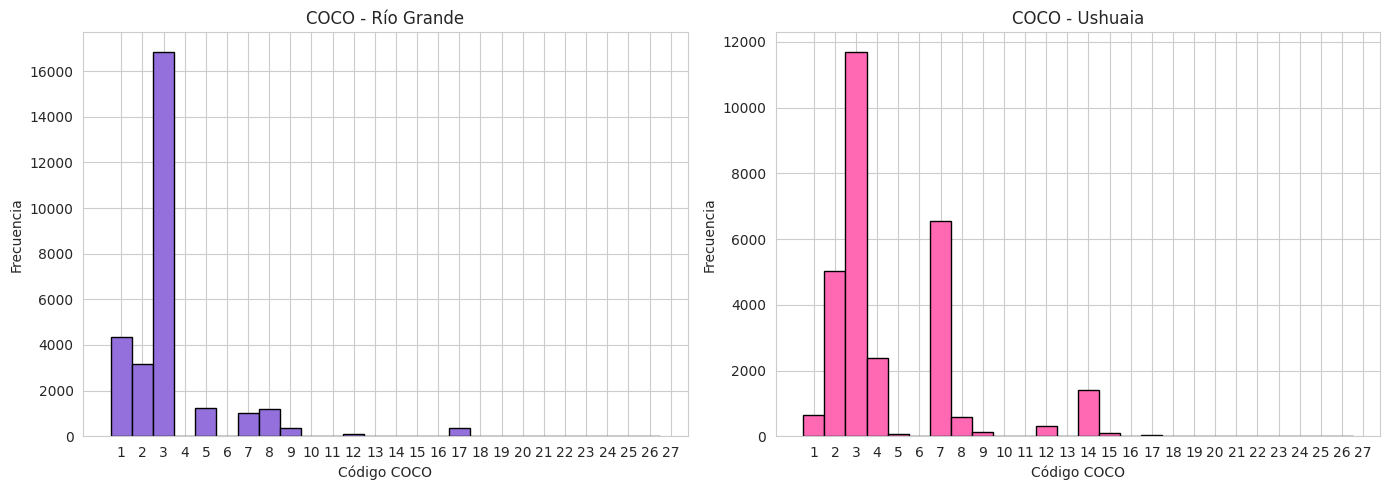

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(14,5))

# Río Grande
ax[0].hist(df_modelo['coco_Rio Grande'],
           bins=np.arange(0.5, 27.5, 1),
           color='mediumpurple',
           edgecolor='black')



# Ushuaia
ax[1].hist(df_modelo['coco_Ushuaia'],
           bins=np.arange(0.5, 27.5, 1),
           color='hotpink',
           edgecolor='black')

ax[1].set_xticks(range(1, 28))
ax[1].set_title('COCO - Ushuaia')
ax[1].set_xlabel('Código COCO')
ax[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

La distribución de los códigos COCO permite visualizar  las condiciones meteorológicas predominantes en Río Grande y Ushuaia durante el período analizado. En ambas localidades se observa un claro predominio de los códigos asociados a condiciones de cielo despejado, poco nuboso y nublado (códigos 1, 2 y 3), siendo este último el más frecuente en los dos casos. Este comportamiento indica que gran parte de las observaciones corresponden a situaciones atmosféricas estables, sin fenómenos meteorológicos severos.

En Río Grande destaca la elevada frecuencia del código 3 (nublado), lo que evidencia una marcada recurrencia de condiciones de cielo cubierto o mayormente nublado. Asimismo, la presencia relativamente importante del código 5 (niebla) sugiere que los episodios de niebla constituyen un fenómeno meteorológico recurrente en la zona. Por su parte, Ushuaia presenta una distribución más diversificada, con una mayor representación de códigos asociados a precipitaciones y fenómenos invernales, particularmente lluvia ligera (código 7), aguanieve intensa (código 13) y nevadas ligeras (código 14).

En un analisis comparativo , los resultados indican que Río Grande se caracteriza por una mayor concentración de observaciones en condiciones nubladas y de niebla, mientras que Ushuaia registra una mayor variedad de fenómenos asociados a la precipitación. Estas diferencias reflejan las particularidades climáticas de cada ciudad  y permiten identificar patrones meteorológicos distintivos a lo largo de los distintos sectores de la Ruta Nacional 3 en Tierra del Fuego.


##Humedad relativa: Río Grande vs Ushuaia

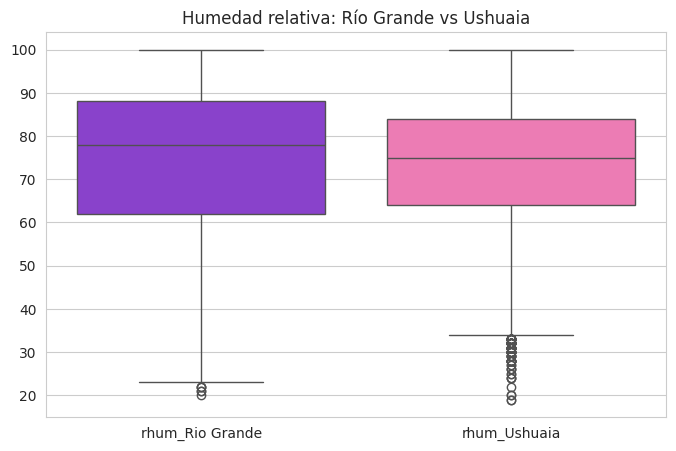

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df_modelo[[
        "rhum_Rio Grande",
        "rhum_Ushuaia"
    ]],
     palette=["#8A2BE2", "#FF69B4"]
)

plt.title("Humedad relativa: Río Grande vs Ushuaia")

plt.show()

El grafico de la humedad relativa deja en evidencia la diferencia leve que hay  entre las condiciones atmosféricas de Río Grande y Ushuaia. Río Grande presenta una tendencia hacia valores de humedad ligeramente más elevados y una mayor concentración de registros en rangos altos, lo que sugiere una atmósfera más cercana a condiciones favorables para la saturación del aire. Por su parte, Ushuaia exhibe una distribución algo más dispersa y una mediana levemente inferior, reflejando una mayor variabilidad en los niveles de humedad. Aunque ambas localidades mantienen condiciones generalmente húmedas, los resultados indican que Río Grande podría presentar una mayor predisposición a alcanzar estados de saturación atmosférica, especialmente cuando estos niveles de humedad se combinan con descensos de temperatura.

## Diferencia entre Temperatura y Dew Point

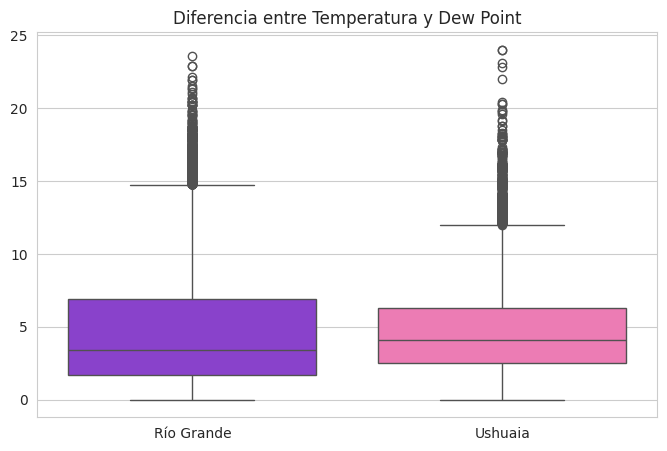

In [ ]:
df_modelo["delta_RG"] = abs(
    df_modelo["temp_Rio Grande"] -
    df_modelo["dwpt_Rio Grande"]
)

df_modelo["delta_USH"] = abs(
    df_modelo["temp_Ushuaia"] -
    df_modelo["dwpt_Ushuaia"]
)

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df_modelo[[
        "delta_RG",
        "delta_USH"
    ]],
    palette=["#8A2BE2", "#FF69B4"]  # violeta RG, rosa USH
)

plt.title(
    "Diferencia entre Temperatura y Dew Point"
)

plt.xticks(
    [0,1],
    ["Río Grande","Ushuaia"]
)

plt.show()

La distribución de la diferencia entre la temperatura del aire y el punto de rocío muestra que Río Grande presenta, en general, valores ligeramente más bajos y una mayor concentración de registros próximos a la saturación atmosférica en comparación con Ushuaia. Esto sugiere que las condiciones favorables para la formación de niebla podrían ocurrir con mayor frecuencia en Río Grande. Por su parte, Ushuaia exhibe una distribución algo más desplazada hacia diferencias mayores, indicando una menor proximidad entre la temperatura ambiente y el punto de rocío.


## Punto de rocio: Rio Grande vs Ushuaia

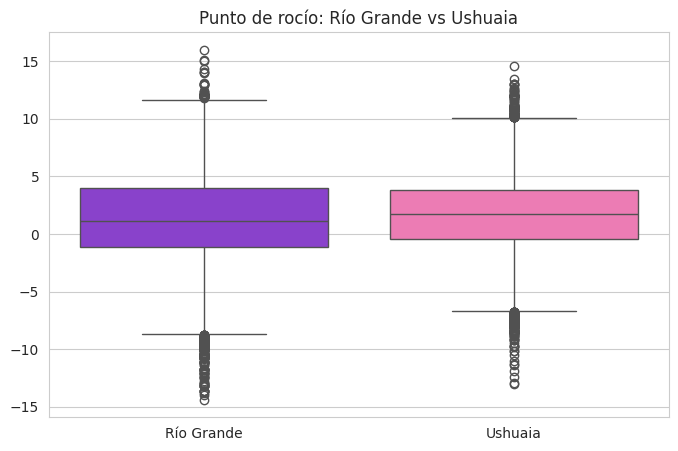

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df_modelo[[
        "dwpt_Rio Grande",
        "dwpt_Ushuaia"
    ]],
    palette=["#8A2BE2", "#FF69B4"]  # violeta RG, rosa USH
)

plt.title("Punto de rocío: Río Grande vs Ushuaia")

plt.xticks(
    [0,1],
    ["Río Grande", "Ushuaia"]
)

plt.show()

El gráfico comparativo del punto de rocío nos muestra que, pese a las diferencias geográficas entre ambas ciudades, existe una similitud notable en las condiciones de humedad atmosférica y en la tendencia del aire a alcanzar la saturación. Ushuaia presenta una mediana ligeramente más elevada y una mayor presencia de valores atípicos bajos, lo que sugiere episodios ocasionales de ingreso de aire más frío y seco provenientes de zonas montañosas, reduciendo temporalmente las probabilidades de condensación. En cambio, Río Grande muestra una distribución más uniforme y una concentración de datos dentro de valores positivos. Este comportamiento refleja una disponibilidad de humedad relativamente constante que, combinada con el enfriamiento radiativo característico de la estepa fueguina, favorece la estabilidad del punto de rocío y aumenta la ocurrencia de fenómenos que afectan la visibilidad, especialmente en el sector norte de la Ruta Nacional 3.


### Distribución de Temperaturas (Ushuaia vs Río Grande)

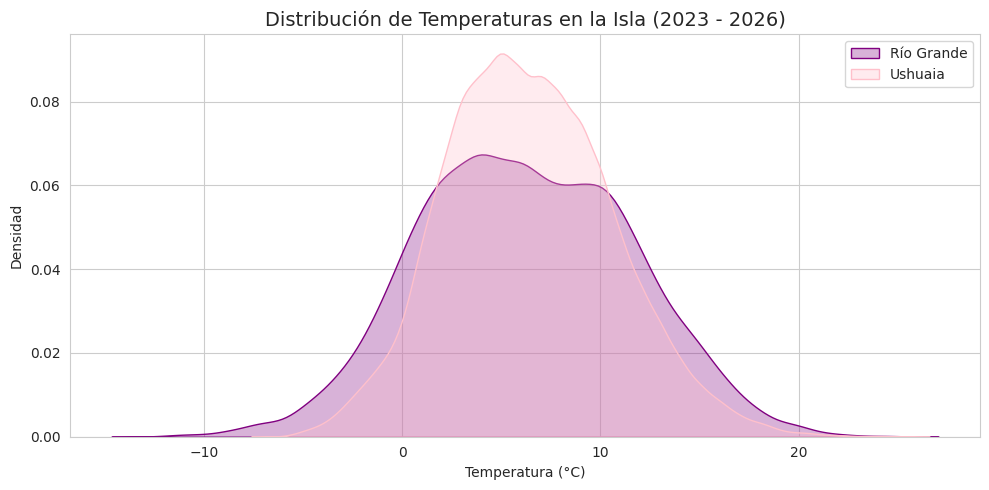

In [ ]:
plt.figure(figsize=(10, 5))
sns.kdeplot(df_modelo['temp_Rio Grande'], label='Río Grande', fill=True, color='purple', alpha=0.3)
sns.kdeplot(df_modelo['temp_Ushuaia'], label='Ushuaia', fill=True, color='pink', alpha=0.3)
plt.title('Distribución de Temperaturas en la Isla (2023 - 2026)', fontsize=14)
plt.xlabel('Temperatura (°C)')
plt.ylabel('Densidad')
plt.legend()
plt.tight_layout()
plt.show()

El gráfico de densidad permite observar las diferencias en el comportamiento de las temperaturas entre Río Grande y Ushuaia. En Río Grande, la distribución es más amplia, lo que indica una mayor variación térmica a lo largo del tiempo, registrándose tanto temperaturas muy bajas como valores más elevados durante los meses cálidos. En cambio, Ushuaia presenta una distribución más concentrada, con temperaturas que tienden a mantenerse dentro de un rango más estable. Esto puede explicarse teniendo en cuenta la influencia marítima del Canal Beagle, que contribuye a moderar las variaciones extremas de temperatura.
Desde el punto de vista del modelo, estas diferencias resultan relevantes ya que permiten identificar patrones climáticos distintos entre ambas ciudades. La combinación de temperaturas registradas en cada localidad puede aportar información útil para detectar la pr


###Relación de Humedad Relativa entre ambas ciudades (Scatter Plot)

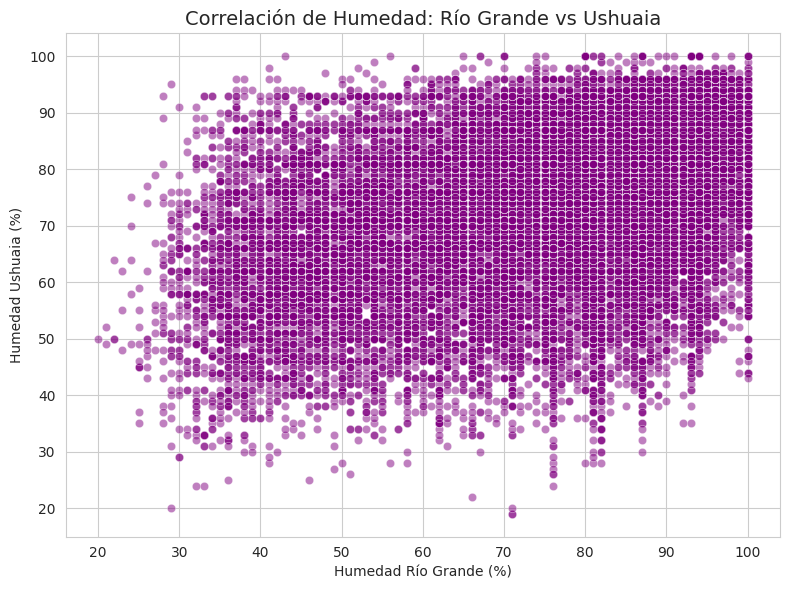

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_modelo, x='rhum_Rio Grande', y='rhum_Ushuaia', alpha=0.5, color='purple')
plt.title('Correlación de Humedad: Río Grande vs Ushuaia', fontsize=14)
plt.xlabel('Humedad Río Grande (%)')
plt.ylabel('Humedad Ushuaia (%)')
plt.tight_layout()
plt.show()

El gráfico de dispersión muestra que la mayor parte de las observaciones se concentra en valores altos de humedad relativa para ambas ciudades. Esto indica que la humedad es una característica frecuente en la región. Sin embargo, también se observan diferencias entre los valores registrados en cada localidad, lo que demuestra que las condiciones atmosféricas no siempre evolucionan de la misma manera.
Para el modelo, esta situación es beneficiosa porque ambas variables aportan información complementaria. Analizar simultáneamente la humedad de Río Grande y Ushuaia puede ayudar a identificar distintos escenarios climáticos que podrían afectar las condiciones de circulación en la Ruta Nacional Nº 3.


###Comportamiento de las Precipitaciones por ciudad

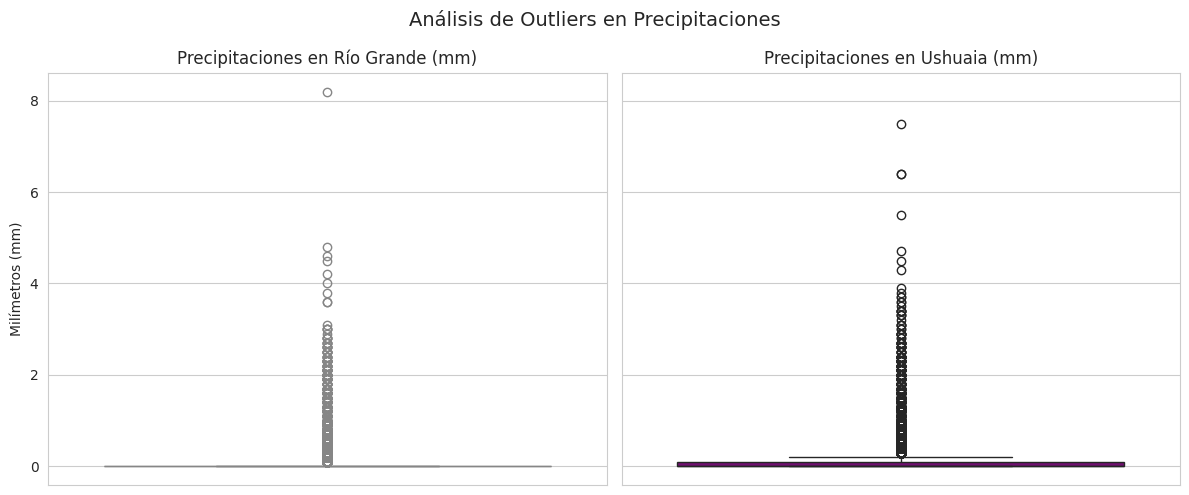

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
sns.boxplot(data=df_modelo, y='prcp_Rio Grande', ax=axes[0], color='pink')
axes[0].set_title('Precipitaciones en Río Grande (mm)')
axes[0].set_ylabel('Milímetros (mm)')

sns.boxplot(data=df_modelo, y='prcp_Ushuaia', ax=axes[1], color='purple')
axes[1].set_title('Precipitaciones en Ushuaia (mm)')

plt.suptitle('Análisis de Outliers en Precipitaciones', fontsize=14)
plt.tight_layout()
plt.show()

Los diagramas de caja muestran que la mayoría de los registros presentan precipitaciones nulas o muy bajas, algo esperable considerando que gran parte de los días no se registran eventos significativos de lluvia o nieve. No obstante, también aparecen valores extremos que representan episodios de precipitaciones más intensas.
Estos valores no fueron considerados errores ni eliminados durante el proceso de limpieza, ya que corresponden a fenómenos meteorológicos reales. Además, resultan especialmente importantes para el proyecto porque pueden estar asociados a situaciones de mayor riesgo para la circulación vehicular. Los modelos seleccionados, como Árboles de Decisión y Random Forest, pueden trabajar adecuadamente con este tipo de valores extremos y utilizarlos para mejorar la identificación de escenarios críticos.


## Frecuencia de eventos extremos

Río Grande: 5.51%
Ushuaia: 1.08%


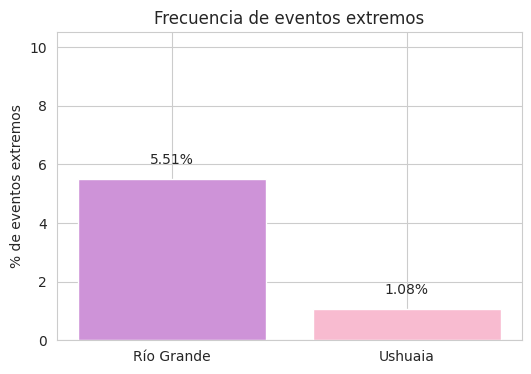

In [ ]:

eventos_extremos = [5, 6, 9, 15, 16, 18, 21, 22, 25, 27]

porc_rg = (
    df_modelo["coco_Rio Grande"]
    .isin(eventos_extremos)
    .mean() * 100
)

porc_ush = (
    df_modelo["coco_Ushuaia"]
    .isin(eventos_extremos)
    .mean() * 100
)

print(f"Río Grande: {porc_rg:.2f}%")
print(f"Ushuaia: {porc_ush:.2f}%")

plt.figure(figsize=(6,4))

plt.bar(
    ["Río Grande", "Ushuaia"],
    [porc_rg, porc_ush],
    color= ["#CE93D8", "#F8BBD0"] # rosa y violeta
)

plt.ylabel("% de eventos extremos")
plt.title("Frecuencia de eventos extremos")
plt.ylim(0, max(porc_rg, porc_ush) + 5)

# Mostrar los valores sobre las barras
for i, valor in enumerate([porc_rg, porc_ush]):
    plt.text(i, valor + 0.5, f"{valor:.2f}%", ha="center")

plt.show()

El gráfico muestra la frecuencia de eventos extremos(niebla, niebla helada, lluvia intensa, nevadas y nevadas intensas, chubascos intensos de lluvia y nieve, chubascos de nieve, tormentas eléctricas y temporales severos, correspondientes a los códigos meteorológicos 5, 6, 9, 15, 16, 18, 21, 22, 25 y 27.) registrada en las dos localidades analizadas. Se observa que Río Grande presenta una proporción ligeramente  mayor de eventos extremos, alcanzando un 5,51 % del total de observaciones, mientras que Ushuaia registra apenas un 1,08 %. Esto indica que los eventos extremos son aproximadamente cinco veces más frecuentes en Río Grande que en Ushuaia, evidenciando una mayor variabilidad o exposición a condiciones extremas en la primera localidad durante el período estudiado.